In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd "/content/drive/MyDrive/meta_data"

/content/drive/MyDrive/meta_data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Calculate mutual information for regression task
from sklearn.feature_selection import mutual_info_regression

In [ ]:
#pd.set_option('display.max_columns', None)

In [ ]:
# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
# 2. INITIAL EXPLORATION & CLEANING
# Initial data inspection
print("=== Initial Data Summary ===")
print(f"Records: {len(df)}")
print(f"Columns: {len(df.columns)}")
print("\nMissing values per column:")
print(df.isnull().sum())

=== Initial Data Summary ===
Records: 180519
Columns: 53

Missing values per column:
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                           

In [ ]:
# Remove unnecessary columns
cols_to_drop = [
    'Product Description', 'Product Image', 'Customer Password', 'Customer Email',
    'Customer Fname', 'Customer Lname', 'Order Zipcode', 'Latitude', 'Longitude'
]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [ ]:
# Remove duplicate helper columns after validation
# Ensure columns are identical
if (df['Customer Id'] == df['Order Customer Id']).all():
    df = df.drop(columns=['Order Customer Id'])
if (df['Product Card Id'] == df['Order Item Cardprod Id']).all():
    df = df.drop(columns=['Order Item Cardprod Id'])

# Remove spaces from column names and fix common issues
df.columns = df.columns.str.replace(' ', '')
df = df.rename(columns={
    'Daysforshipping(real)': 'DaysForShippingReal','Daysforshipment(scheduled)' : 'DaysForShipmentScheduled'
})

In [ ]:
# 3. HANDLE MISSING VALUES
# -----------------------------

# Fill missing CustomerZipcode with string "0.0"
df['CustomerZipcode'] = df['CustomerZipcode'].fillna('0.0')

In [ ]:
# change to datetime format
df['orderdate(DateOrders)'] = pd.to_datetime(df['orderdate(DateOrders)'])
df['shippingdate(DateOrders)'] = pd.to_datetime(df['shippingdate(DateOrders)'])

In [ ]:
# 5. ROUND NUMERIC COLUMNS
# -----------------------------

two_decimals = [
    'Benefitperorder', 'OrderItemDiscount', 'OrderItemProductPrice',
    'Sales', 'OrderItemTotal', 'OrderProfitPerOrder', 'ProductPrice'
]
six_decimals = [
    'OrderItemDiscountRate', 'OrderItemProfitRatio',
]

# Round
df[two_decimals] = df[two_decimals].round(2)
df[six_decimals] = df[six_decimals].round(6)

In [ ]:
df.columns

Index(['Type', 'DaysForShippingReal', 'DaysForShipmentScheduled',
       'Benefitperorder', 'Salespercustomer', 'DeliveryStatus',
       'Late_delivery_risk', 'CategoryId', 'CategoryName', 'CustomerCity',
       'CustomerCountry', 'CustomerId', 'CustomerSegment', 'CustomerState',
       'CustomerStreet', 'CustomerZipcode', 'DepartmentId', 'DepartmentName',
       'Market', 'OrderCity', 'OrderCountry', 'orderdate(DateOrders)',
       'OrderId', 'OrderItemDiscount', 'OrderItemDiscountRate', 'OrderItemId',
       'OrderItemProductPrice', 'OrderItemProfitRatio', 'OrderItemQuantity',
       'Sales', 'OrderItemTotal', 'OrderProfitPerOrder', 'OrderRegion',
       'OrderState', 'OrderStatus', 'ProductCardId', 'ProductCategoryId',
       'ProductName', 'ProductPrice', 'ProductStatus',
       'shippingdate(DateOrders)', 'ShippingMode'],
      dtype='object')

In [ ]:
df[["ProductCardId","ProductCategoryId","ProductName"]].nunique()

,0
ProductCardId,118
ProductCategoryId,51
ProductName,118


In [ ]:
# @title Feature Engineering of Demand Forecast

In [ ]:
# Define Target Feature

# Extract year and month for monthly aggregation
df['year_month'] = df['orderdate(DateOrders)'].dt.to_period('M')
# Convert year_month to string for clarity
df['year_month'] = df['year_month'].astype(str)

# Aggregate OrderItemQuantity by ProductName, OrderRegion, and year_month
demand_df = df.groupby(['year_month', 'ProductCardId', 'OrderCountry'])['OrderItemQuantity'].sum().reset_index()
demand_df.rename(columns={'OrderItemQuantity': 'Demand'}, inplace=True)

# Sort for clarity
demand_df = demand_df.sort_values(['year_month', 'ProductCardId', 'OrderCountry'])

In [ ]:
demand_df.info()
all_product_ids = demand_df['ProductCardId'].unique()
order_countries = demand_df['OrderCountry'].unique()

all_product_ids, order_countries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15955 entries, 0 to 15954
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   year_month     15955 non-null  object
 1   ProductCardId  15955 non-null  int64 
 2   OrderCountry   15955 non-null  object
 3   Demand         15955 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 498.7+ KB


(array([  37,   44,   93,  116,  134,  135,  172,  191,  235,  249,  273,
         276,  278,  282,  365,  403,  502,  564,  565,  567,  572,  627,
         642,  703,  728,  771,  775,  778,  792,  793,  797,  804,  810,
         818,  821,  822,  823,  825,  828,  835,  885,  886,  893,  897,
         905,  906,  917,  924,  926,  957,  977, 1004, 1014, 1073,   19,
          24,   35,   78,  216,  251,  258,  295,  305,  306,  311,  359,
         607,  625,  646,  647,  652,  666,  671,  677,  691,  705,  715,
         724,  725,  730,  743,  773,  777,  786,  858,  981,  982,   58,
          60,   61,  127,  203,  208,  226,  303,  364,  768,  845,  860,
        1059, 1346, 1347, 1348, 1349, 1350, 1351, 1352, 1353, 1354, 1355,
        1356, 1357, 1358, 1359, 1360, 1361, 1362, 1363]),
 array(['Colombia', 'Guatemala', 'México', 'República Dominicana',
        'Brasil', 'Cuba', 'El Salvador', 'Nicaragua', 'Panamá', 'Uruguay',
        'Argentina', 'Chile', 'Haití', 'Honduras', 'Jamaica'

Perform feature engineering for other features

In [ ]:
# Temporal Features

# Month of year
demand_df['month'] = pd.to_datetime(demand_df['year_month'] + '-01').dt.month

# Peak/Holiday season flag (1/0)
demand_df['PeakSeason'] = demand_df['month'].isin([11, 12]).astype(int)  # Nov-Dec

# Product Features
# These capture product specific characteristics, those influence demand.

# Product popularity (total demand across all regions)
product_popularity = df.groupby('ProductCardId')['OrderItemQuantity'].sum().rename('product_total_demand')
demand_df = demand_df.merge(product_popularity, on='ProductCardId', how='left')

# Average product price
price_per_product = df.groupby('ProductCardId')['ProductPrice'].mean().rename('avg_product_price')
demand_df = demand_df.merge(price_per_product, on='ProductCardId', how='left')

# Average discount rate
discount_rate = df.groupby(['year_month', 'ProductCardId'])['OrderItemDiscountRate'].mean().reset_index(name='avg_discount_rate')
demand_df = demand_df.merge(discount_rate, on=['year_month', 'ProductCardId'], how='left')

# Country Features
# Country popularity (total demand across all products)
country_popularity = df.groupby('OrderCountry')['OrderItemQuantity'].sum().rename('country_total_demand')
demand_df = demand_df.merge(country_popularity, on='OrderCountry', how='left')

# Target encode OrderCountry
country_means = df.groupby('OrderCountry')['OrderItemQuantity'].mean().rename('country_avg_demand')
demand_df = demand_df.merge(country_means, on='OrderCountry', how='left')

# Country order frequency (number of orders per country-month)
order_freq = df.groupby(['year_month', 'OrderCountry'])['OrderId'].nunique().reset_index(name='country_order_count')
demand_df = demand_df.merge(order_freq, on=['year_month', 'OrderCountry'], how='left')

# Target encode ProductCategoryId
category_means = df.groupby('ProductCategoryId')['OrderItemQuantity'].mean().rename('category_avg_demand')
demand_df = demand_df.merge(df[['ProductCardId', 'ProductCategoryId']].drop_duplicates(), on='ProductCardId', how='left')
demand_df = demand_df.merge(category_means, on='ProductCategoryId', how='left')
demand_df.drop(columns=['ProductCategoryId'], inplace=True)

# Customer purchase frequency (average orders per customer)
cust_orders = df.groupby(['year_month', 'OrderCountry', 'CustomerId'])['OrderId'].nunique().reset_index(name='order_count')
cust_freq = cust_orders.groupby(['year_month', 'OrderCountry'])['order_count'].mean().reset_index(name='avg_customer_orders')
demand_df = demand_df.merge(cust_freq, on=['year_month', 'OrderCountry'], how='left')

# Order and Delivery Features
# Average late delivery risk
late_delivery_risk = df.groupby(['year_month', 'ProductCardId', 'OrderCountry'])['Late_delivery_risk'].mean().reset_index(name='avg_late_delivery_risk')
demand_df = demand_df.merge(late_delivery_risk, on=['year_month', 'ProductCardId', 'OrderCountry'], how='left')

# Average shipping time
shipping_time = df.groupby(['year_month', 'OrderCountry'])['DaysForShippingReal'].mean().reset_index(name='avg_shipping_time')
demand_df = demand_df.merge(shipping_time, on=['year_month', 'OrderCountry'], how='left')

In [ ]:
demand_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15955 entries, 0 to 15954
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year_month              15955 non-null  object 
 1   ProductCardId           15955 non-null  int64  
 2   OrderCountry            15955 non-null  object 
 3   Demand                  15955 non-null  int64  
 4   month                   15955 non-null  int32  
 5   PeakSeason              15955 non-null  int64  
 6   product_total_demand    15955 non-null  int64  
 7   avg_product_price       15955 non-null  float64
 8   avg_discount_rate       15955 non-null  float64
 9   country_total_demand    15955 non-null  int64  
 10  country_avg_demand      15955 non-null  float64
 11  country_order_count     15955 non-null  int64  
 12  category_avg_demand     15955 non-null  float64
 13  avg_customer_orders     15955 non-null  float64
 14  avg_late_delivery_risk  15955 non-null

In [ ]:
product_card_id = ['ProductCardId']
num_features = demand_df.drop(columns=['ProductCardId', 'PeakSeason']).select_dtypes(include=['float64','int32', 'int64']).columns.tolist()
bool_features = ['PeakSeason']
ignored_features=["year_month", "OrderCountry"]
target_feature = ['Demand']

feature_lst = num_features+bool_features

#df_final = df[order_item_id+num_features+cat_features+bool_features+target_features]

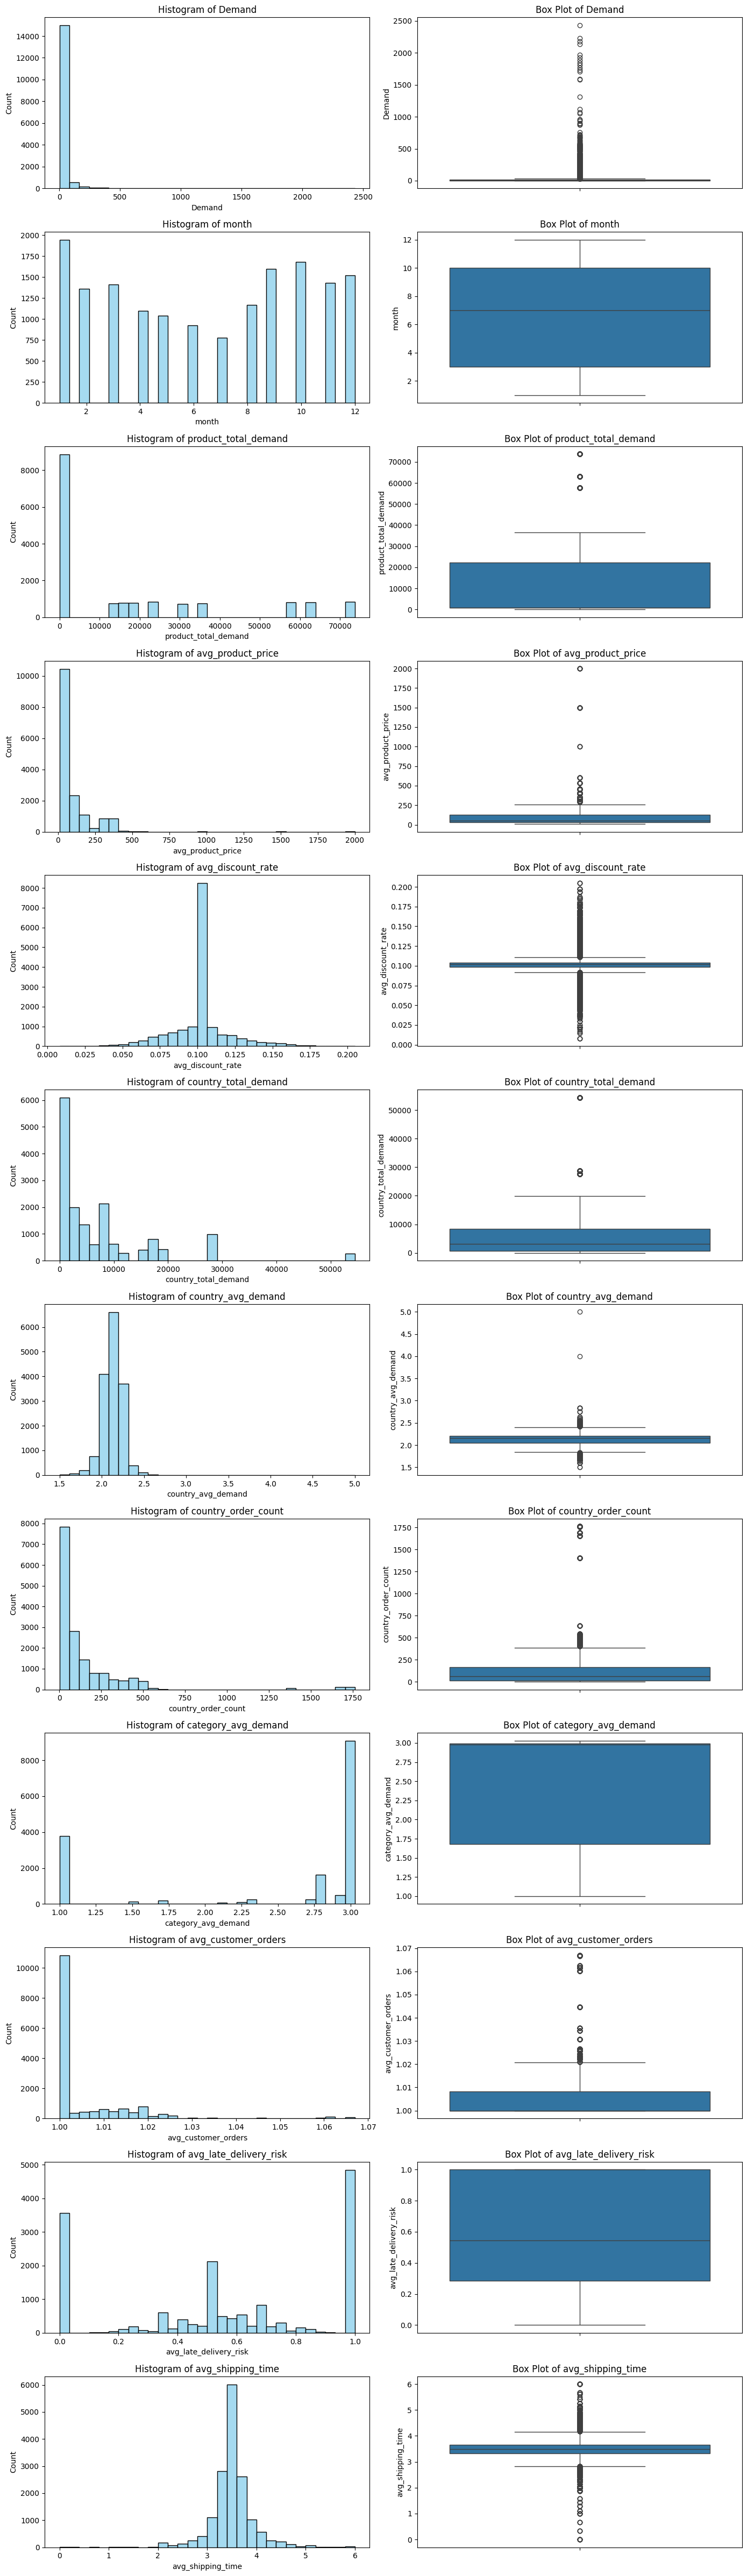

In [ ]:
# @title Outlier detection

# Plotting histograms and boxplots
# Calculate the figure layout based on the number of columns
def Visualize_box_hist(df, n_cols, n_rows, num_clos):

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))

    # Loop through each numerical column and plot both histogram and boxplot
    for i, column in enumerate(num_clos):
        # Plot histogram on the left
        sns.histplot(df[column], bins=30, color='skyblue', ax=axes[i, 0])
        axes[i, 0].set_title(f'Histogram of {column}')

        # Plot boxplot on the right
        sns.boxplot(y=df[column], ax=axes[i, 1])
        axes[i, 1].set_title(f'Box Plot of {column}')

    # Adjust layout for better readability
    plt.tight_layout()
    plt.show()

n_cols = 2  # Number of columns per row
n_rows = len(num_features)  # Calculate required rows
Visualize_box_hist(demand_df, n_cols, n_rows, num_features)

In the above Visualization we can decide as follows:

Histogram Analysis:
If the histogram shows a strong right skew (a long tail toward higher values):
Log Transformation is likely a good choice, as it can reduce skewness by compressing higher values.
If the histogram appears nearly symmetric with a few extreme values on the right:
Capping may be more suitable, as it can control the impact of these extreme values without altering the overall distribution.

Box Plot Analysis:
If the box plot shows many points beyond the upper whisker, indicating frequent outliers:
Log Transformation may help if these are high-value outliers, as it can scale them down and reduce their influence.
If the box plot has only a few points as outliers but they are significantly distant from the box:
Capping might be sufficient to handle these isolated high values without altering the overall shape of the data.

In [ ]:
# IQR Method to count how many outliers are there for each feature

# Dictionary to store the count of outliers for each column
outliers_count = {}
outliers_count_after = {}

# we need these list for later dealing outliers in pipeline
remove_outliers = []
cap_outliers = []
#transform_outliers = []

for cols in num_features:
    Q1 = demand_df[cols].quantile(0.25)
    Q3 = demand_df[cols].quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = int(demand_df[(demand_df[cols] < lower_bound) | (demand_df[cols] > upper_bound)].shape[0])
    outliers_count[cols] = {'Num of Outliers': outliers}

    if cols == "Demand": # Demand is target feature. Thus we always apply transformation for target feature.
        #transform_outliers.append(cols)
        demand_df[cols] = np.log1p(demand_df[cols])  # Log transformation
    else:
        # no outliers so nothing to do here
        if outliers == 0:
            pass
        # here we remove outliers
        elif outliers > 0 and outliers < 21:
            remove_outliers.append(cols)
            # Remove rows where a certain feature is outside bounds
            demand_df = demand_df[(demand_df[cols] >= lower_bound) & (demand_df[cols] <= upper_bound)]
        # here we cap outliers
        else:
            cap_outliers.append(cols)
            demand_df[cols] = np.where(demand_df[cols] < lower_bound, lower_bound, demand_df[cols])
            demand_df[cols] = np.where(demand_df[cols] > upper_bound, upper_bound, demand_df[cols])


    # Re-evaluate IQR for Consistency
    outliers_after = demand_df[(demand_df[cols] < lower_bound) | (demand_df[cols] > upper_bound)]
    outliers_count_after[cols] = {'Num of Outliers after': outliers_after.shape[0]}

print(pd.DataFrame(outliers_count).T)
print(remove_outliers)
print(cap_outliers)
#print(transform_outliers)

print(pd.DataFrame(outliers_count_after).T)

                        Num of Outliers
Demand                             2311
month                                 0
product_total_demand               2462
avg_product_price                  1839
avg_discount_rate                  5843
country_total_demand               1247
country_avg_demand                  489
country_order_count                1372
category_avg_demand                   0
avg_customer_orders                 921
avg_late_delivery_risk                0
avg_shipping_time                  1507
[]
['product_total_demand', 'avg_product_price', 'avg_discount_rate', 'country_total_demand', 'country_avg_demand', 'country_order_count', 'avg_customer_orders', 'avg_shipping_time']
                        Num of Outliers after
Demand                                      0
month                                       0
product_total_demand                        0
avg_product_price                           0
avg_discount_rate                           0
country_total_demand 

In above, we Show first number of outliers for each features.\
For Features with a Very High Count of Outliers (≥ 200): we use Transformation method. \
For Features with Moderate Outlier Counts (21 - 199): we use Cap the Outliers method.\
For Features with Low to Moderate Outlier Counts (1 - 20): we use Remove Outliers.

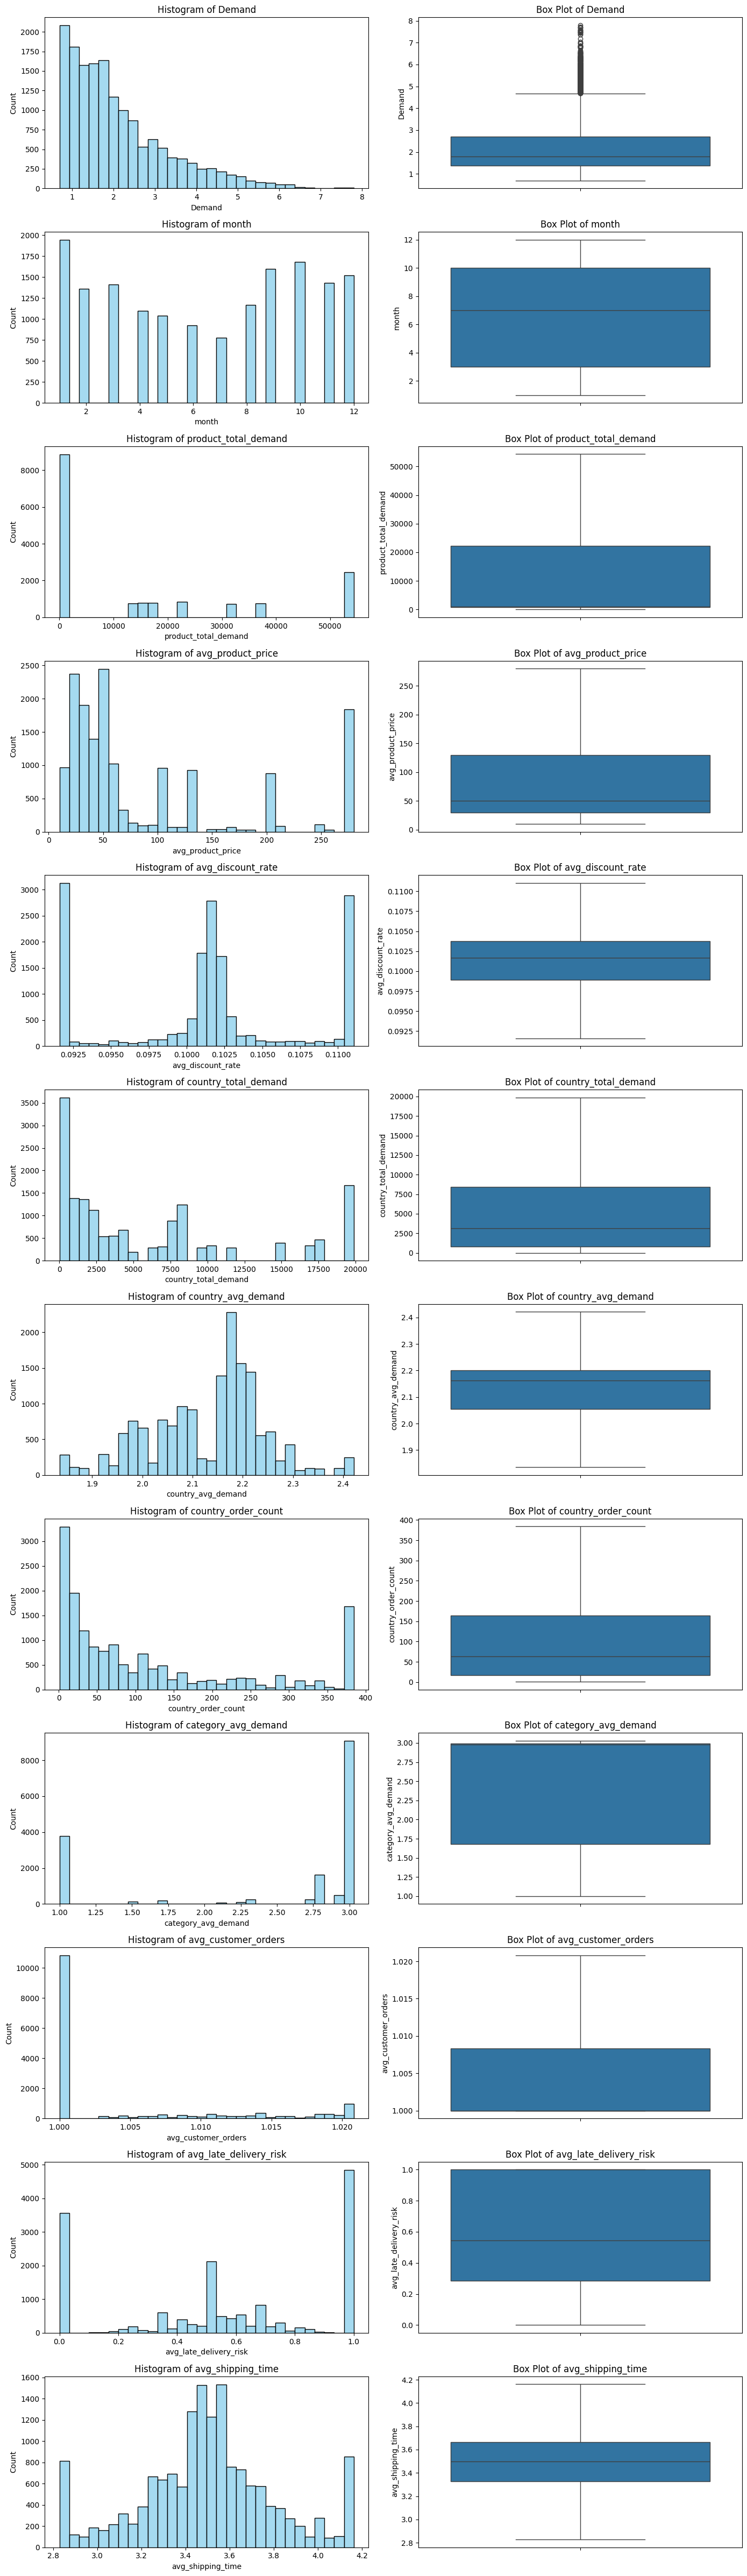

In [ ]:
n_cols = 2  # Number of columns per row
n_rows = len(num_features)  # Calculate required rows
Visualize_box_hist(demand_df, n_cols, n_rows, num_features)

### Feature Scaling

### Deal with Numerical Features

First we visualize wheather all features are normally distributed. If they are normally distributed, then we perform Standardization otherwise we will perform Normalization.

Standardize features close to normal distributions. Skewness is close to 0 (between -0.5 and 0.5), and kurtosis is also within a reasonable range (typically between -1 and +1)

Normalize features with higher skewness and kurtosis extremes. Features with higher skewness (|skewness| > 0.5) and/or more extreme kurtosis values (kurtosis less than -1.5 or greater than 1.5)

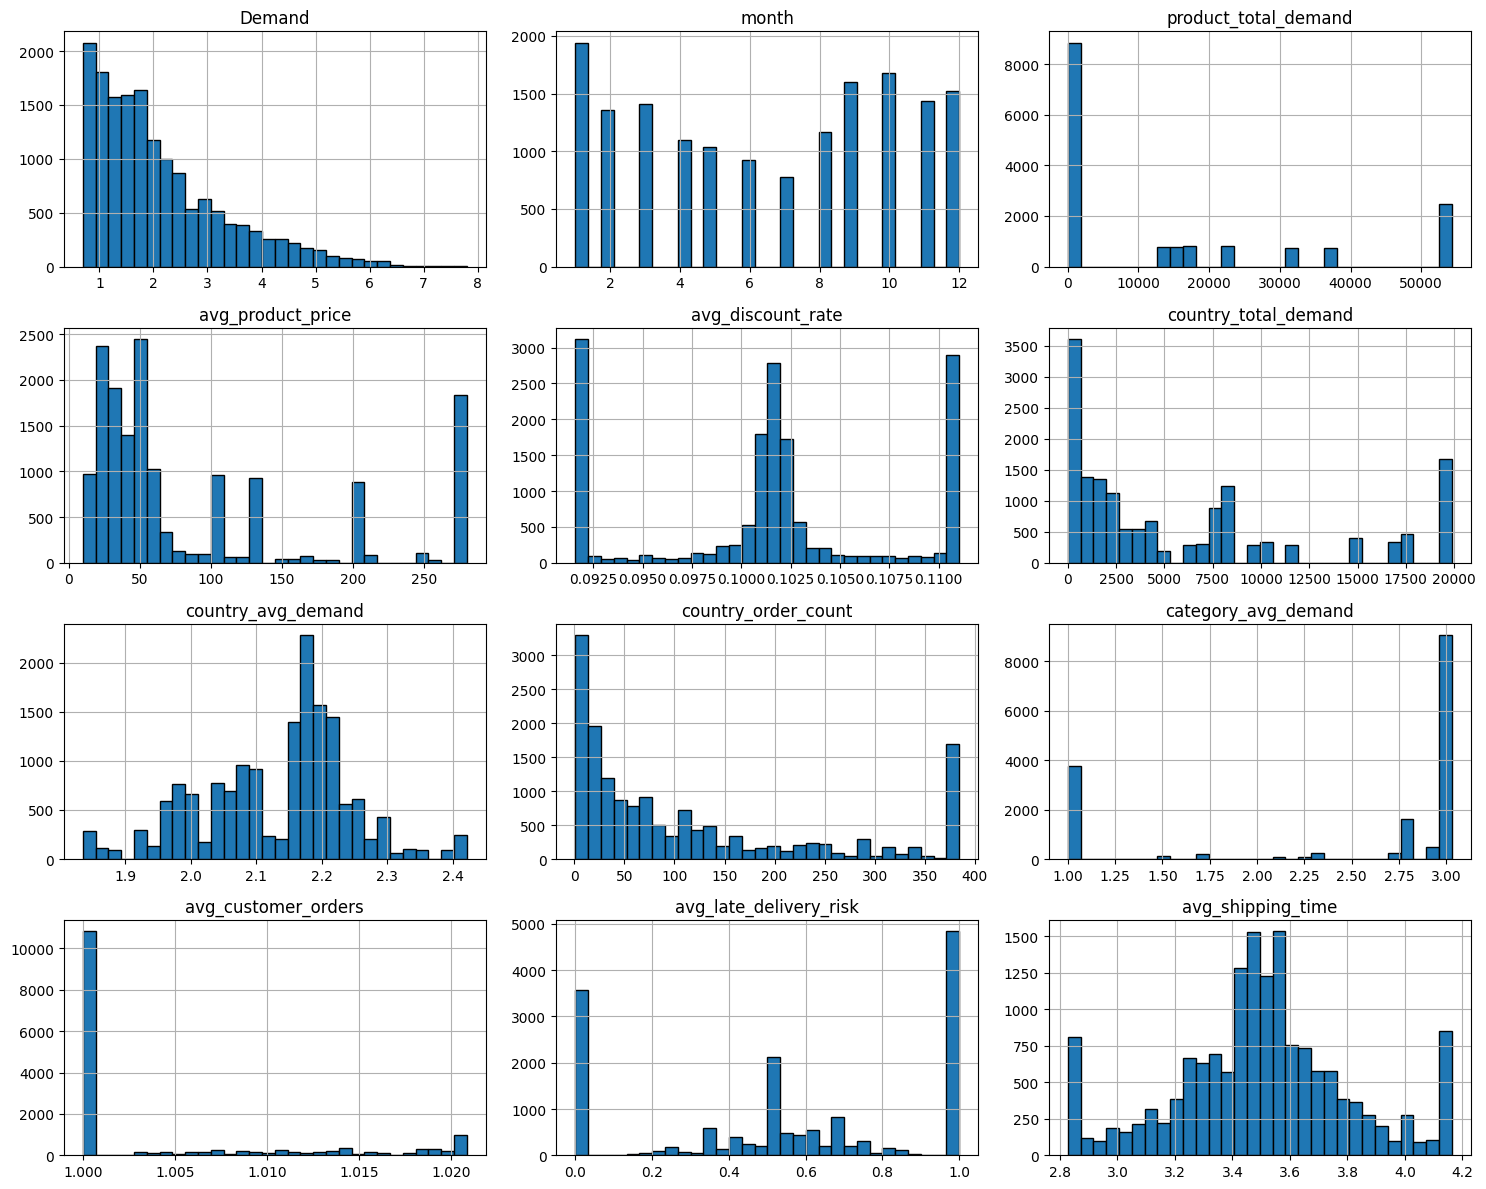

In [ ]:
# plot histograms
demand_df[num_features].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

In [ ]:
# Check Skewness and Kurtosis
for column in num_features:
    skewness = demand_df[column].skew()
    kurtosis = demand_df[column].kurtosis()
    print(f"{column} - Skewness: {skewness}, Kurtosis: {kurtosis}")

Demand - Skewness: 1.18268807873146, Kurtosis: 1.217163689088741
month - Skewness: -0.06988621855200587, Kurtosis: -1.405848272671577
product_total_demand - Skewness: 1.0473392677391054, Kurtosis: -0.4010787485207561
avg_product_price - Skewness: 1.305348186140524, Kurtosis: 0.2978383883644615
avg_discount_rate - Skewness: -0.07551134420008658, Kurtosis: -0.7714159322384209
country_total_demand - Skewness: 1.0301266660757826, Kurtosis: -0.2794040628432888
country_avg_demand - Skewness: -0.2770751535867092, Kurtosis: 0.03708586201954844
country_order_count - Skewness: 1.1282800421132269, Kurtosis: -0.08039745488394257
category_avg_demand - Skewness: -1.0738664392008461, Kurtosis: -0.7559982901628479
avg_customer_orders - Skewness: 1.2930462575884913, Kurtosis: 0.07771418365889815
avg_late_delivery_risk - Skewness: -0.2358832982784178, Kurtosis: -1.2495922280298282
avg_shipping_time - Skewness: -0.003045543125627783, Kurtosis: 0.15386000270232092


From the histogram and Skewness-Kurtosis test, we can decide-

Standardization: month, avg_shipping_time, country_avg_demand.

Normalization: Demand, product_total_demand, avg_product_price, country_total_demand, country_order_count, category_avg_demand, avg_customer_orders.

For Standarization we will perform StandardScaler and for Normalization we perform MinMaxScaler.

StandardScaler → can produce negative (<0) and >1 values (z‑scores).

MinMaxScaler → forces everything into the [0, 1] interval.

In [ ]:
norm_target_features = ['Demand']
norm_features = ['product_total_demand', 'avg_product_price', 'country_total_demand', 'country_order_count', 'category_avg_demand', 'avg_customer_orders']
stand_features = ['month', 'avg_shipping_time', 'country_avg_demand']

### Pipeline for Scaling and Encoding

We use Pipeline as we are working with multiple encoding techniques. It allows us to organize our preprocessing steps systematically and ensure consistency across both training and prediction phases.

In [ ]:
# ColumnTransformer for separate scaling
preprocessor = ColumnTransformer(transformers=[
    ('norm_target', MinMaxScaler(), norm_target_features),
    ('norm', MinMaxScaler(), norm_features),
    ('std',  StandardScaler(), stand_features)
], remainder='passthrough') # Keep the other columns (if any) as it is

In [ ]:
# Full pipeline
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor)
])

# Fit and transform
preprocessed_data = pipeline.fit_transform(demand_df)

In [ ]:
# Recover the output feature names
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
column_names = [name.split('__', 1)[1] if '__' in name else name
    for name in feature_names]
column_names

['Demand',
 'product_total_demand',
 'avg_product_price',
 'country_total_demand',
 'country_order_count',
 'category_avg_demand',
 'avg_customer_orders',
 'month',
 'avg_shipping_time',
 'country_avg_demand',
 'year_month',
 'ProductCardId',
 'OrderCountry',
 'PeakSeason',
 'avg_discount_rate',
 'avg_late_delivery_risk']

In [ ]:
# Build a DataFrame
df_transformed = pd.DataFrame(
    preprocessed_data,
    columns=column_names,
    index=demand_df.index
)
df_transformed.head(5)

,Demand,product_total_demand,avg_product_price,country_total_demand,country_order_count,category_avg_demand,avg_customer_orders,month,avg_shipping_time,country_avg_demand,year_month,ProductCardId,OrderCountry,PeakSeason,avg_discount_rate,avg_late_delivery_risk
0,0.097575,0.014195,0.092598,0.194908,0.229465,0.898963,0.545455,-1.482107,-0.110725,0.500253,2015-01,37,Colombia,0,0.111042,1.0
1,0.226562,0.014195,0.092598,0.306198,0.19296,0.898963,0.0,-1.482107,-0.68677,0.523892,2015-01,37,Guatemala,0,0.111042,1.0
2,0.057078,0.014195,0.092598,1.0,1.0,0.898963,0.993103,-1.482107,0.051479,0.472666,2015-01,37,México,0,0.111042,1.0
3,0.128987,0.014195,0.092598,0.406219,0.362451,0.898963,0.345324,-1.482107,0.979394,0.607339,2015-01,37,República Dominicana,0,0.111042,1.0
4,0.252228,0.017103,0.185195,0.875528,0.659713,0.898963,0.189723,-1.482107,0.536652,0.412964,2015-01,44,Brasil,0,0.097333,0.5


In [ ]:
df_transformed.dtypes

,0
Demand,object
product_total_demand,object
avg_product_price,object
country_total_demand,object
country_order_count,object
category_avg_demand,object
avg_customer_orders,object
month,object
avg_shipping_time,object
country_avg_demand,object


In [ ]:
# Convert the numerical columns to float
df_transformed[num_features] = df_transformed[num_features].astype(float)

# make order item id as integer
df_transformed['ProductCardId'] = df_transformed['ProductCardId'].astype(int)
df_transformed['PeakSeason'] = df_transformed['PeakSeason'].astype(int)

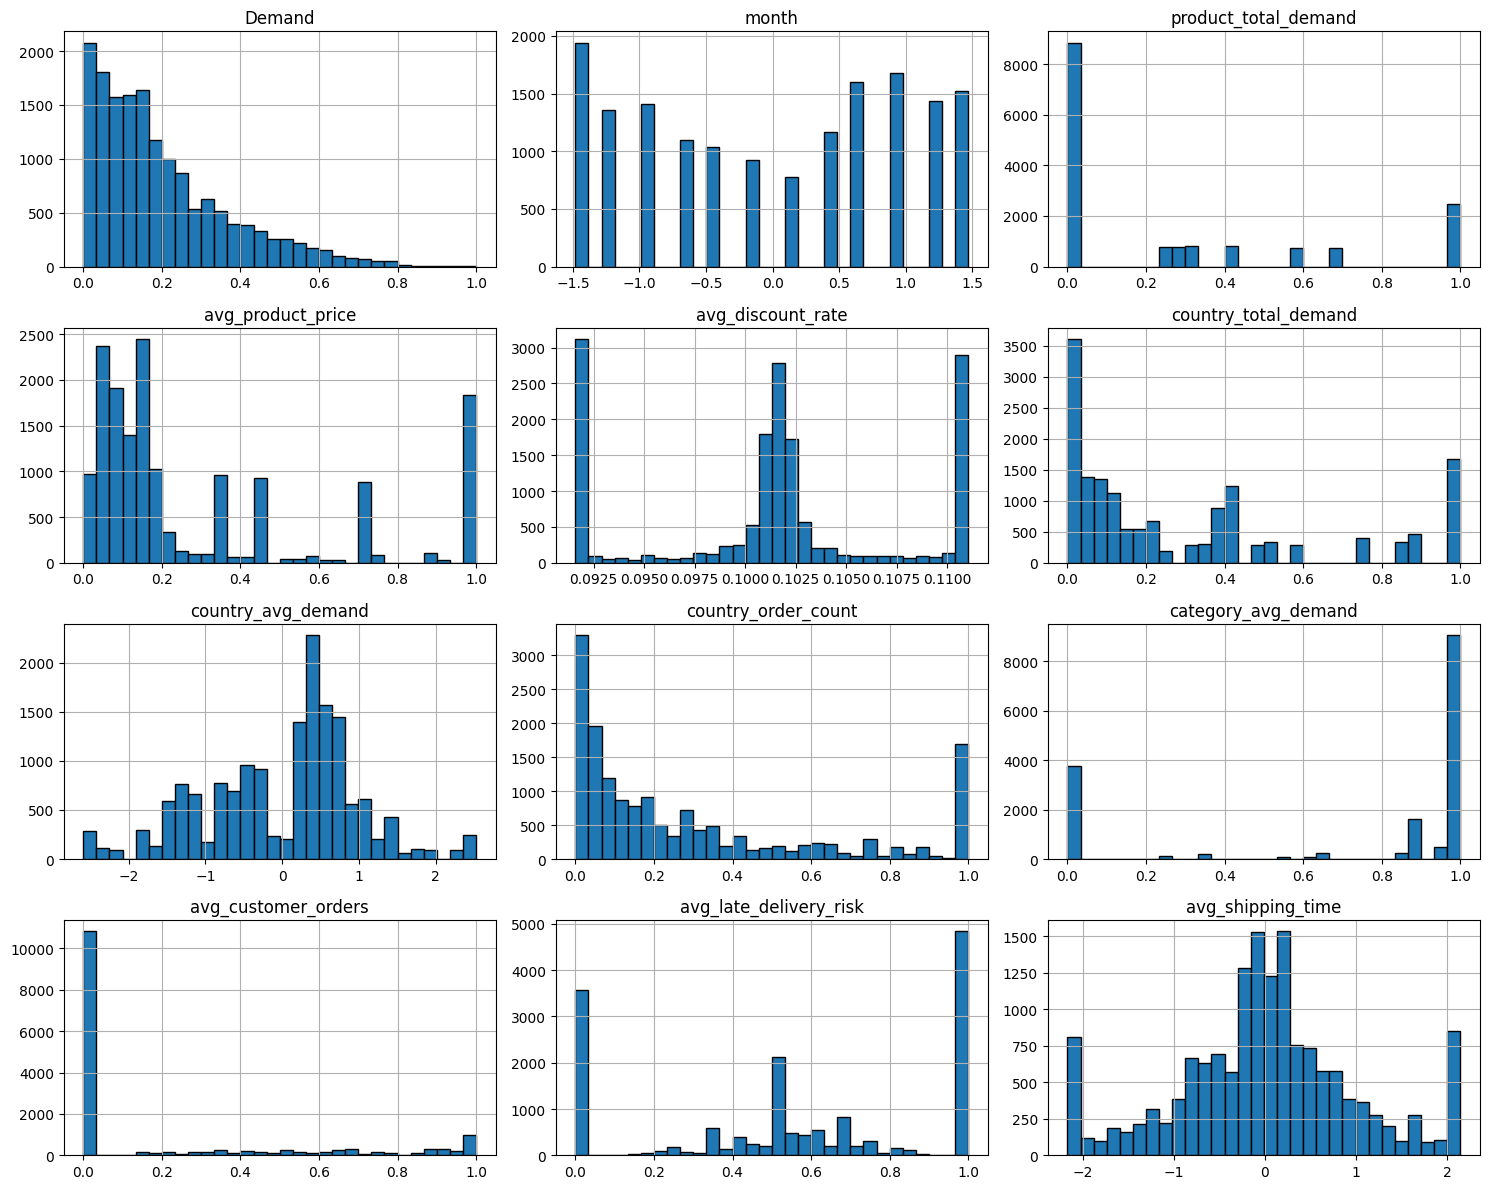

In [ ]:
# plot histograms after Scaling
df_transformed[num_features].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

### Feature Selection with Mutual Information

In [ ]:
# define features and targets
features = df_transformed.drop(columns=target_feature+product_card_id+ignored_features).columns.tolist()
targets = target_feature

mi_target = mutual_info_regression(df_transformed[features], df_transformed[target_feature].values.ravel(), discrete_features='auto', n_neighbors=5)

# The output lists the features from most important (highest mutual information) to least important (lowest mutual information) in relation to predicting 'Demand'.
selected_indices = np.argsort(mi_target)[::-1] # Sort in descending order

#df_transformed[features].columns[selected_indices]

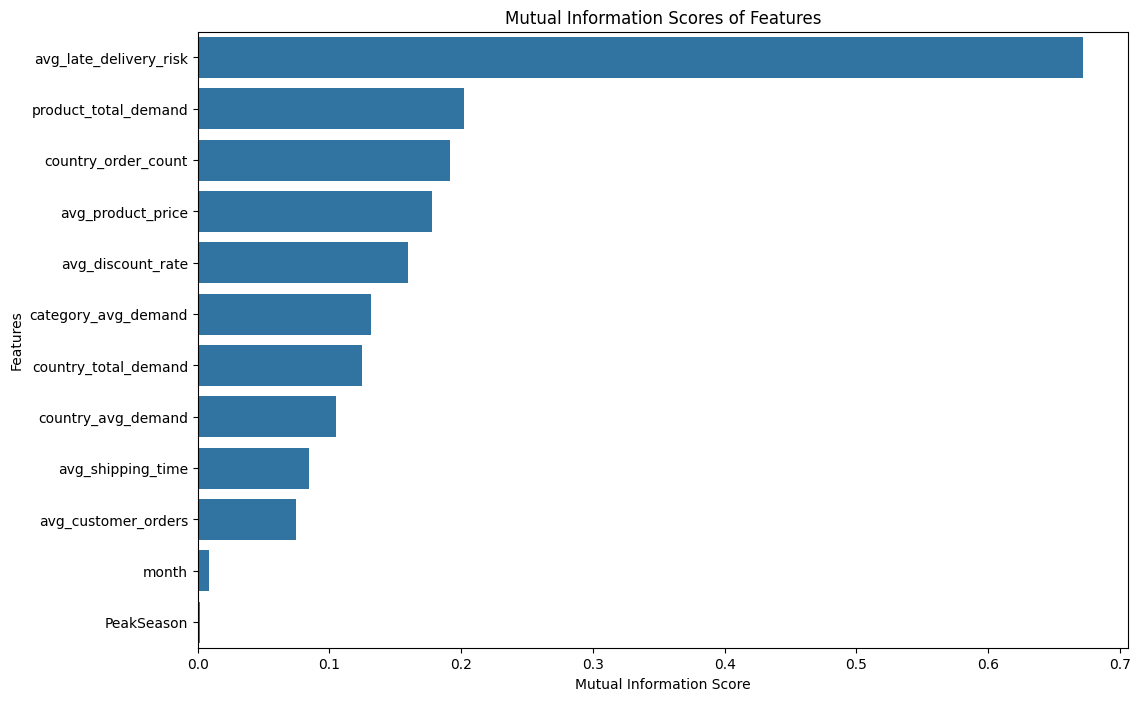

In [ ]:
# Get the feature names and their mutual information scores
feature_names = df_transformed[features].columns[selected_indices]
mi_scores = mi_target[selected_indices]

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=mi_scores, y=feature_names)
plt.title('Mutual Information Scores of Features')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.show()

In [ ]:
# Based on feature selection we remove feature those Mi score is less than 0.05
# Identify features to keep based on MI score threshold
features_to_remove = feature_names[mi_scores < 0.05].tolist()

# Filter the DataFrame
df_transformed.drop(columns=features_to_remove, inplace=True)
df_transformed.columns

Index(['Demand', 'product_total_demand', 'avg_product_price',
       'country_total_demand', 'country_order_count', 'category_avg_demand',
       'avg_customer_orders', 'avg_shipping_time', 'country_avg_demand',
       'year_month', 'ProductCardId', 'OrderCountry', 'avg_discount_rate',
       'avg_late_delivery_risk'],
      dtype='object')

Save preprocessed dataset

In [ ]:
df_transformed.to_pickle('preprocessed_data_demand_forecast.pkl')

In [ ]:
# Save the pipeline for later denormalisation of Target feature
# Define the filename for the pipeline
pipeline_filename = 'demand_forecast_pipeline.pkl'

# Save the pipeline to a file
joblib.dump(pipeline, pipeline_filename)

['demand_forecast_pipeline.pkl']

In [ ]:
df_prep = pd.read_pickle('preprocessed_data_demand_forecast.pkl')

df_prep.dtypes

,0
Demand,float64
product_total_demand,float64
avg_product_price,float64
country_total_demand,float64
country_order_count,float64
category_avg_demand,float64
avg_customer_orders,float64
avg_shipping_time,float64
country_avg_demand,float64
year_month,object
